In [1]:
from zipfile import ZipFile
import requests
import os 
import io
import datetime
import dateutil
import time
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("fire.csv")

C:\Users\Elowe\AppData\Local\Temp\ipykernel_30836\2948116887.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("fire.csv")


In [3]:
df.columns

Index(['_id', 'Incident_Number', 'Initial_CAD_Event_Type',
       'Final_Incident_Type', 'Exposures', 'Incident_Station_Area',
       'Incident_Ward', 'Intersection', 'Latitude', 'Longitude',
       'Property_Use', 'Building_Status', 'TFS_Alarm_Time', 'TFS_Arrival_Time',
       'Ext_agent_app_or_defer_time', 'Fire_Under_Control_Time',
       'Last_TFS_Unit_Clear_Time', 'Number_of_responding_apparatus',
       'Number_of_responding_personnel', 'Count_of_Persons_Rescued',
       'TFS_Firefighter_Casualties', 'Civilian_Casualties',
       'Estimated_Number_Of_Persons_Displaced', 'Estimated_Dollar_Loss',
       'Business_Impact', 'Status_of_Fire_On_Arrival',
       'Method_Of_Fire_Control', 'Area_of_Origin', 'Level_Of_Origin',
       'Extent_Of_Fire', 'Smoke_Spread', 'Ignition_Source',
       'Material_First_Ignited', 'Possible_Cause',
       'Smoke_Alarm_at_Fire_Origin',
       'Smoke_Alarm_at_Fire_Origin_Alarm_Failure',
       'Smoke_Alarm_at_Fire_Origin_Alarm_Type',
       'Smoke_Alarm_

In [130]:
from sklearn.model_selection import train_test_split
time_cols = ['TFS_Alarm_Time', 'TFS_Arrival_Time', 'Fire_Under_Control_Time', 'Hourly_Timestamp']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

df['Control_Duration'] = (df['Fire_Under_Control_Time'] - df['TFS_Arrival_Time']).dt.total_seconds()

df['Hour_of_Day'] = df['Hourly_Timestamp'].dt.hour
df['is_weekend'] = df['Hourly_Timestamp'].dt.dayofweek >= 5

def categorize_event(x):
    x = str(x)
    if "Fire" in x or x.startswith("FI"):
        return "Fire"
    else:
        return "Other"

df["Event_Category"] = df["Initial_CAD_Event_Type"].apply(categorize_event)
df = df[df["Event_Category"]=="Fire"]

df_train_val, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42)

df_analysis = df_train[(df_train['Control_Duration'] > 0) & (df_train['Control_Duration'] < 14400)].copy()

In [131]:
df_analysis.isnull().sum()

_id                                                                 0
Incident_Number                                                     0
Initial_CAD_Event_Type                                              0
Final_Incident_Type                                                 0
Exposures                                                        8641
Incident_Station_Area                                               0
Incident_Ward                                                      33
Intersection                                                        0
Latitude                                                            0
Longitude                                                           0
Property_Use                                                        0
Building_Status                                                  2762
TFS_Alarm_Time                                                      0
TFS_Arrival_Time                                                    0
Ext_agent_app_or_def

In [92]:
df_analysis['Smoke_Spread'].unique()

array(['2 - Confined to part of room/area of origin', '99 - Undetermined',
       nan, '7 - Spread to other floors, confined to building',
       '4 - Spread beyond room of origin, same floor',
       '8 - Entire Structure', '10 - Spread beyond building of origin',
       '3 - Spread to entire room of origin',
       '5 - Multi unit bldg: spread beyond suite of origin but not to separated suite(s)',
       '9 - Confined to roof/exterior structure',
       '6 - Multi unit bldg: spread to separate suite(s)'], dtype=object)

In [60]:
print(df_analysis["Initial_CAD_Event_Type"].value_counts())

Initial_CAD_Event_Type
FIR                                       3509
FIHR                                      1549
Fire - Residential                        1405
FICI                                      1170
FIG                                       1170
Vehicle Fire                               733
Fire -  Highrise Residential               545
Fire - Grass/Rubbish                       484
Fire - Commercial/Industrial               454
Vehicle Fire - Highway                     253
FIHRD                                      131
FITP                                       103
FIO                                         99
FIS                                         85
FIOS                                        57
FIG2                                        46
FII                                         43
FIHV                                        42
Fire - Highrise Residential - Downtown      37
Fire - Transformer/Pole                     35
Fire - Other                         

In [86]:
print(df_analysis["Intersection"].value_counts())

Intersection
Sherbourne St / Shuter St / Moss Park Trl        38
Chalkfarm Dr / Marlington Cres                   24
Wellesley St E / Bleecker St                     21
Lido Rd / Arrow Rd                               19
Jane St / Eddystone Ave                          18
                                                 ..
Danforth Ave / Eldon Ave                          1
Faustina Dr / Twenty Second St                    1
Glen Park Ave / Glencairn Ave / Hillmount Ave     1
Bloor St W / Kennedy Park Rd                      1
Eugene St / Joyce Pkwy                            1
Name: count, Length: 6822, dtype: int64


In [88]:
print(df_analysis["Property_Use"].value_counts())

Property_Use
301 - Detached Dwelling                              2215
323 - Multi-Unit Dwelling - Over 12 Units            1981
302 - Semi-Detached Dwelling                          691
848 - Trash/Rubbish/Garbage Container or Dumpster     613
323 - Multi-Unit Dwelling Over 12 Units               590
                                                     ... 
675 - Mfg: Sporting Goods or Toys                       1
638 - Mfg:Sugar Refining /Sugar Product                 1
122 - Dance Studio                                      1
673 - Mfg: Precision Goods/Instruments                  1
529 - Book/Stationary/Art Supply Store                  1
Name: count, Length: 315, dtype: int64


In [90]:
print(df_analysis["Building_Status"].value_counts())

Building_Status
01 - Normal (no change)               7943
08 - Not Applicable                    558
02 - Under Renovation                  427
03 - Under Construction                123
05 - Abandoned, vacant (long term)      99
09 - Undetermined                       92
04 - Under Demolition                   13
Name: count, dtype: int64


In [83]:
df_analysis['Incident_Station_Area'] = df_analysis['Incident_Station_Area'].astype(int)

EDA with Visuals

In [61]:
df_analysis.dtypes

_id                                                                       int64
Incident_Number                                                          object
Initial_CAD_Event_Type                                                   object
Final_Incident_Type                                                      object
Exposures                                                               float64
Incident_Station_Area                                                    object
Incident_Ward                                                           float64
Intersection                                                             object
Latitude                                                                float64
Longitude                                                               float64
Property_Use                                                             object
Building_Status                                                          object
TFS_Alarm_Time                          

In [62]:
df_analysis.describe()

,_id,Exposures,Incident_Ward,Latitude,Longitude,TFS_Alarm_Time,TFS_Arrival_Time,Fire_Under_Control_Time,Number_of_responding_apparatus,Number_of_responding_personnel,...,Civilian_Casualties,Estimated_Number_Of_Persons_Displaced,Estimated_Dollar_Loss,Duration,Hourly_Timestamp,temperature_2m,snowfall,precipitation,Control_Duration,Hour_of_Day
count,12280.000000,2828.000000,12243.000000,12280.000000,12280.000000,12280,12280,12280,12280.000000,12280.000000,...,9833.000000,9255.000000,1.225300e+04,12280.000000,12280,12280.000000,12280.000000,12280.000000,12280.000000,12280.000000
mean,16601.745928,0.179632,16.004901,43.704436,-79.396119,2018-03-08 10:40:02.698696960,2018-03-08 10:45:14.441612544,2018-03-08 10:59:09.902524416,8.714088,28.938436,...,0.093562,18.369638,3.856978e+04,311.742915,2018-03-08 10:09:50.423452672,9.994137,0.009286,0.086311,835.460912,13.074104
min,2.000000,0.000000,0.000000,0.000000,-79.636530,2011-01-01 00:06:48,2011-01-01 00:12:54,2011-01-01 01:54:00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,-962.000000,2011-01-01 00:00:00,-24.500000,0.000000,0.000000,1.000000,0.000000
25%,8601.500000,0.000000,7.000000,43.663619,-79.482070,2014-09-13 00:35:14.750000128,2014-09-13 00:39:33.750000128,2014-09-13 01:09:20.249999872,5.000000,18.000000,...,0.000000,0.000000,3.500000e+02,251.000000,2014-09-13 00:15:00,1.800000,0.000000,0.000000,190.000000,8.000000
50%,15390.500000,0.000000,14.000000,43.701640,-79.406573,2018-07-08 05:37:22,2018-07-08 05:44:00.500000,2018-07-08 05:51:30,6.000000,22.000000,...,0.000000,0.000000,3.500000e+03,301.000000,2018-07-08 05:00:00,9.900000,0.000000,0.000000,402.000000,14.000000
75%,24283.750000,0.000000,23.000000,43.751462,-79.331410,2021-06-17 16:44:58.750000128,2021-06-17 16:49:11.500000,2021-06-17 17:14:53.249999872,11.000000,36.000000,...,0.000000,2.000000,2.000000e+04,360.000000,2021-06-17 16:00:00,19.100000,0.000000,0.000000,870.000000,18.000000
max,36543.000000,6.000000,44.000000,43.855400,0.000000,2024-12-31 22:51:15,2024-12-31 22:55:05,2024-12-31 23:39:00,175.000000,537.000000,...,8.000000,999.000000,1.300000e+07,17871.000000,2024-12-31 22:00:00,33.300000,3.360000,12.600000,14379.000000,23.000000
std,9878.651439,0.573173,10.693192,0.397958,0.724094,NaN,NaN,NaN,7.463139,23.496998,...,0.391623,125.729751,2.077062e+05,195.146807,NaN,10.487151,0.083364,0.404826,1336.318460,6.629728


In [65]:
import plotly.express as px

df_map = df_analysis.dropna(subset=['Latitude', 'Longitude', 'Control_Duration', "Estimated_Dollar_Loss"])

df_map = df_map[df_map['Control_Duration'] < 7200]

fig = px.scatter_mapbox(df_map, 
                        lat="Latitude", 
                        lon="Longitude", 
                        color="Control_Duration", 
                        size="Estimated_Dollar_Loss",
                        color_continuous_scale=px.colors.cyclical.IceFire, 
                        size_max=15, 
                        zoom=10,
                        mapbox_style="carto-positron",
                        title="Fire distribution",
                        hover_data=['Final_Incident_Type', 'Property_Use'])
fig.show()

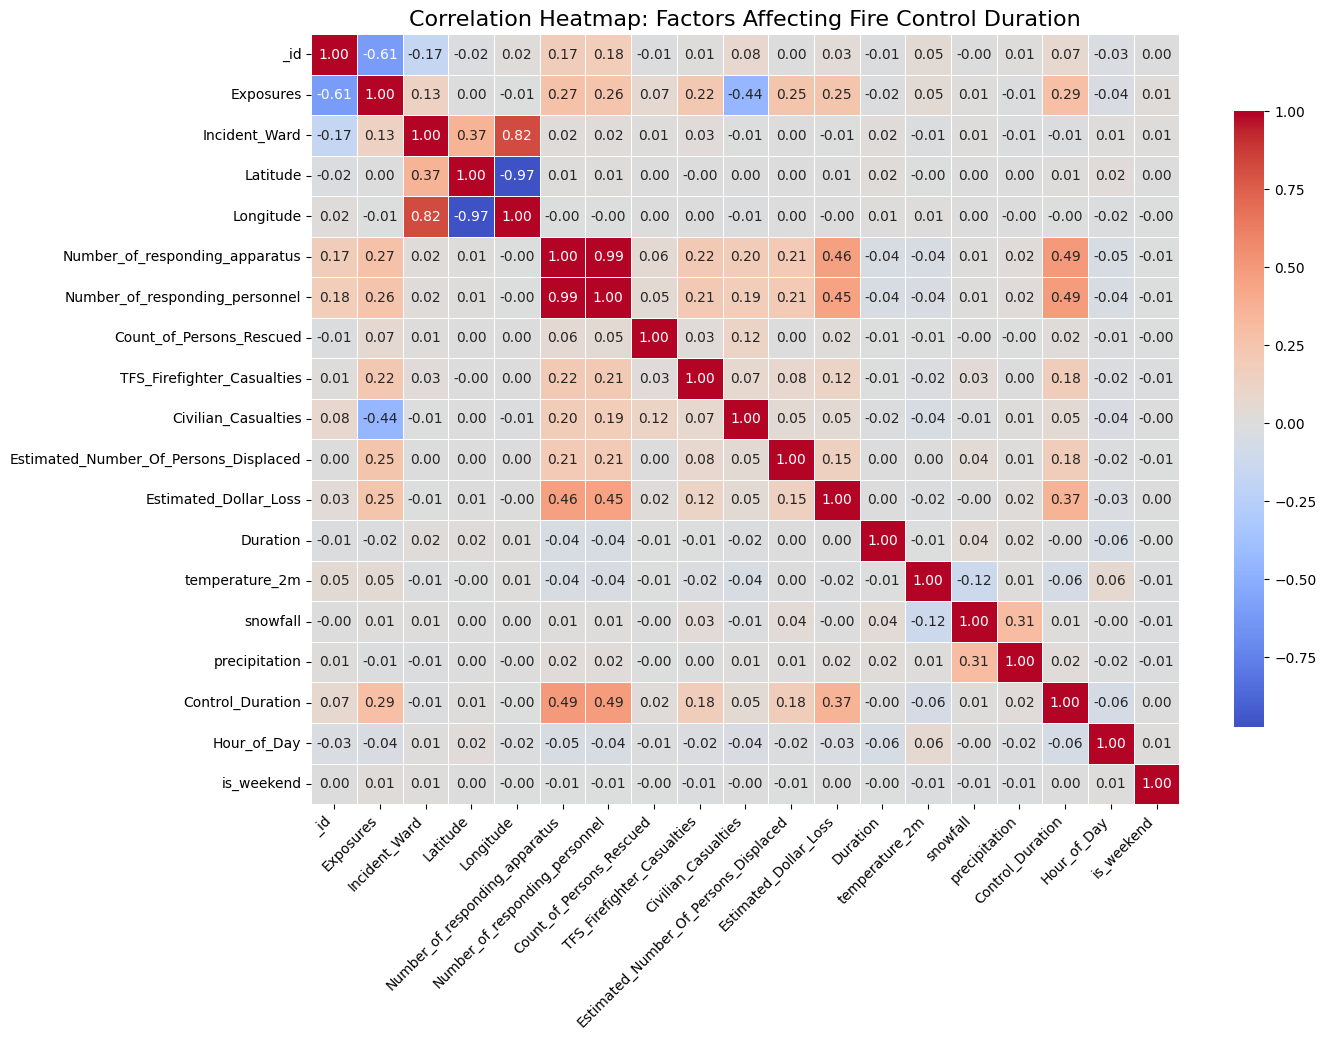

In [66]:
corr_matrix = df_analysis.corr(numeric_only=True)
plt.figure(figsize=(14, 10))

sns.heatmap(corr_matrix, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm', 
            center=0,
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap: Factors Affecting Fire Control Duration', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

Text(0, 0.5, 'Frequency')

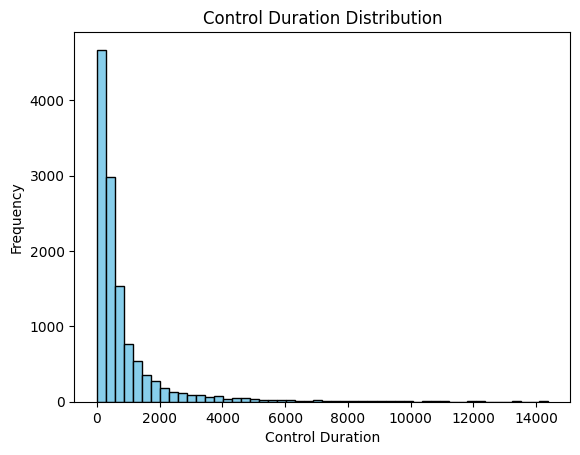

In [67]:
plt.hist(df_analysis["Control_Duration"], bins=50, color='skyblue', edgecolor='black')
plt.title("Control Duration Distribution")
plt.xlabel("Control Duration")
plt.ylabel("Frequency")

In [103]:
df_analysis['Property_Use'].value_counts()

Property_Use
301 - Detached Dwelling                              2215
323 - Multi-Unit Dwelling - Over 12 Units            1981
302 - Semi-Detached Dwelling                          691
848 - Trash/Rubbish/Garbage Container or Dumpster     613
323 - Multi-Unit Dwelling Over 12 Units               590
                                                     ... 
675 - Mfg: Sporting Goods or Toys                       1
638 - Mfg:Sugar Refining /Sugar Product                 1
122 - Dance Studio                                      1
673 - Mfg: Precision Goods/Instruments                  1
529 - Book/Stationary/Art Supply Store                  1
Name: count, Length: 315, dtype: int64

In [106]:
top_property = df_analysis["Property_Use"].value_counts().nlargest(4).index

df_analysis["Property_Group"] = df_analysis["Property_Use"].where(
    df_analysis["Property_Use"].isin(top_property),
    "Other"
)

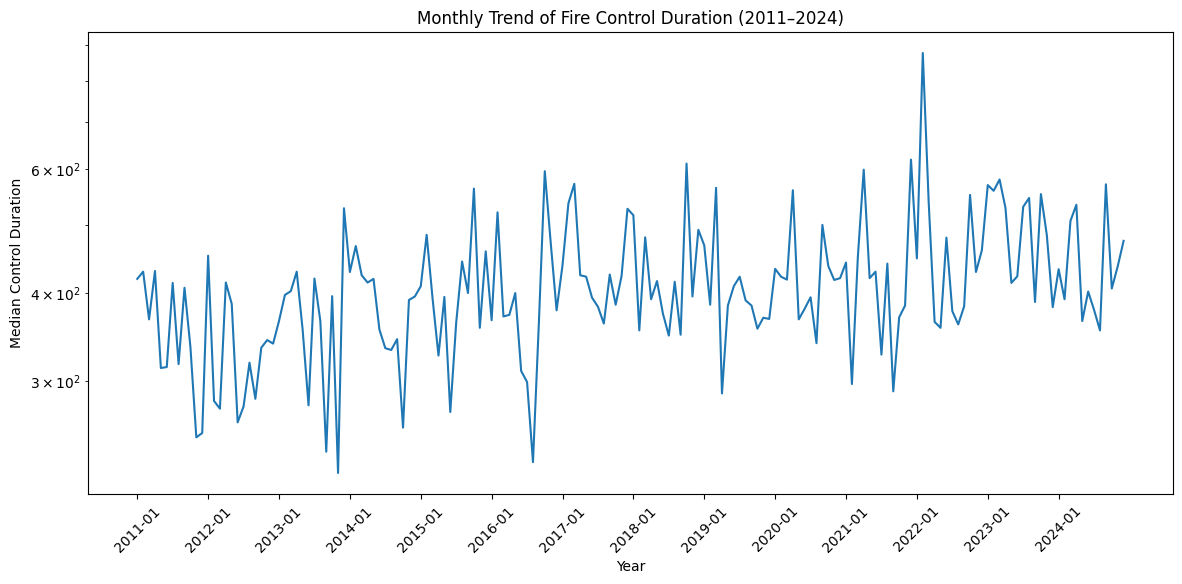

In [118]:
df_analysis["Year_Month"] = df_analysis["TFS_Alarm_Time"].dt.to_period("M")
monthly_duration = (
    df_analysis
    .groupby("Year_Month")["Control_Duration"]
    .median()
    .reset_index()
)

monthly_duration["Year_Month"] = monthly_duration["Year_Month"].astype(str)
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_duration,
    x=range(len(monthly_duration)),
    y="Control_Duration"
)

plt.yscale("log")

plt.xticks(
    ticks=range(0, len(monthly_duration), 12),
    labels=monthly_duration["Year_Month"][::12],
    rotation=45
)

plt.xlabel("Year")
plt.ylabel("Median Control Duration")
plt.title("Monthly Trend of Fire Control Duration (2011–2024)")

plt.show()

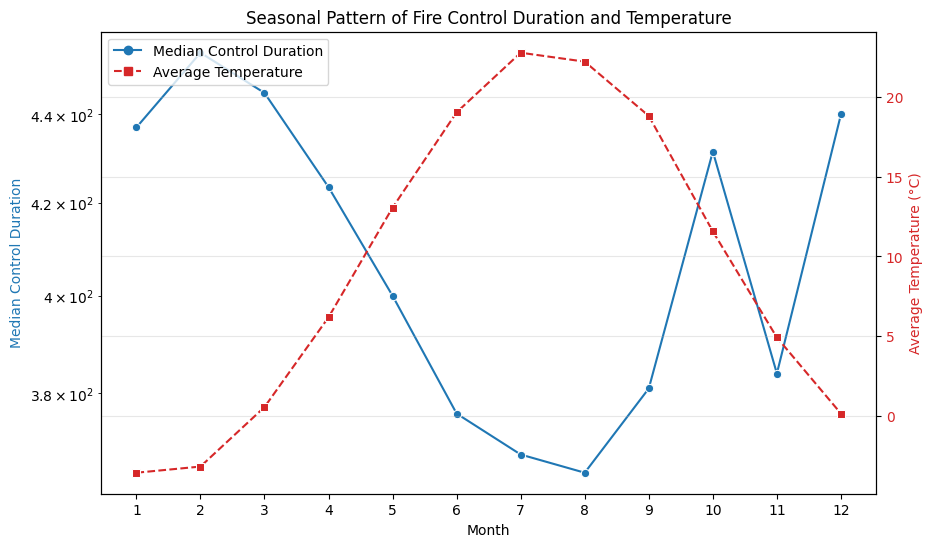

In [ ]:
from matplotlib.lines import Line2D
df_analysis["Month"] = df_analysis["TFS_Alarm_Time"].dt.month
monthly_stats = (
    df_analysis
    .groupby("Month")
    .agg(
        median_duration=("Control_Duration", "median"),
        mean_temperature=("temperature_2m", "mean")
    )
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(10,6))
line1 = sns.lineplot(
    data=monthly_stats,
    x="Month",
    y="median_duration",
    marker="o",
    ax=ax1,
    color="tab:blue"
)

ax1.set_yscale("log")
ax1.set_xlabel("Month")
ax1.set_ylabel("Median Control Duration", color="tab:blue")
ax1.set_xticks(range(1,13))
ax1.set_title("Seasonal Pattern of Fire Control Duration and Temperature")
ax1.tick_params(axis='y', labelcolor="tab:blue")

ax2 = ax1.twinx()
line2 = sns.lineplot(
    data=monthly_stats,
    x="Month",
    y="mean_temperature",
    marker="s",
    linestyle="--",
    ax=ax2,
    color="tab:red"
)

ax2.set_ylabel("Average Temperature (°C)", color="tab:red")
ax2.tick_params(axis='y', labelcolor="tab:red")
legend_elements = [
    Line2D([0], [0], color="tab:blue", marker="o", label="Median Control Duration"),
    Line2D([0], [0], color="tab:red", marker="s", linestyle="--", label="Average Temperature")
]
ax1.legend(handles=legend_elements, loc="upper left")

plt.grid(alpha=0.3)
plt.show()

<Axes: xlabel='Number_of_responding_personnel', ylabel='Control_Duration'>

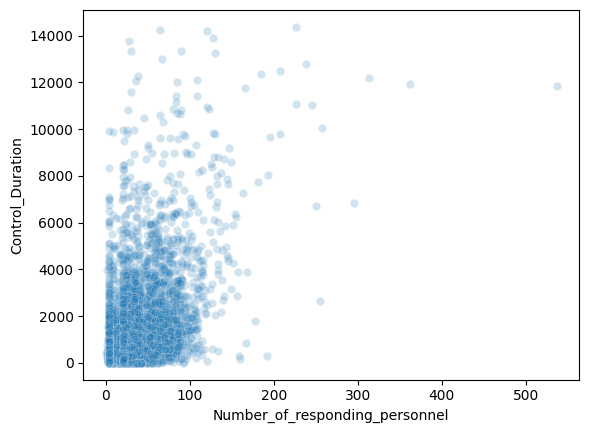

In [100]:
sns.scatterplot(
    data=df_analysis,
    x="Number_of_responding_personnel",
    y="Control_Duration",
    alpha=0.2
)

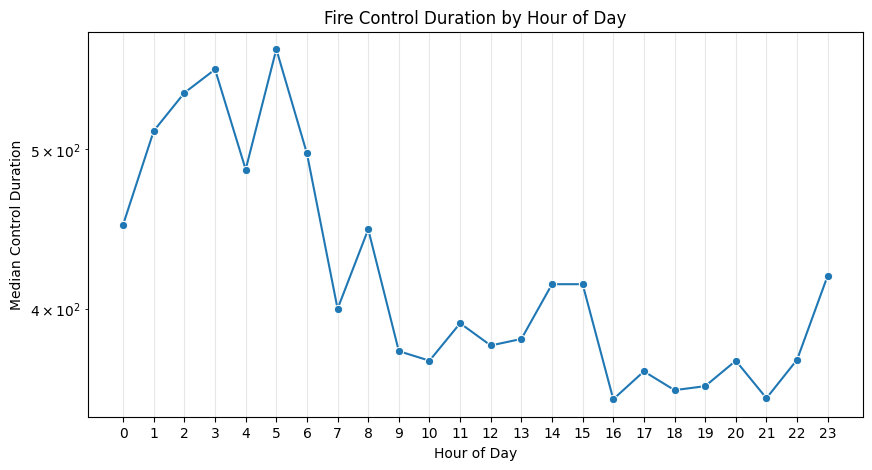

In [102]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_analysis,
    x="Hour_of_Day",
    y="Control_Duration",
    estimator="median",
    errorbar=None,
    marker="o"
)

plt.yscale("log")
plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Median Control Duration")
plt.title("Fire Control Duration by Hour of Day")
plt.grid(alpha=0.3)

plt.show()

<Axes: xlabel='Hour_of_Day', ylabel='Control_Duration'>

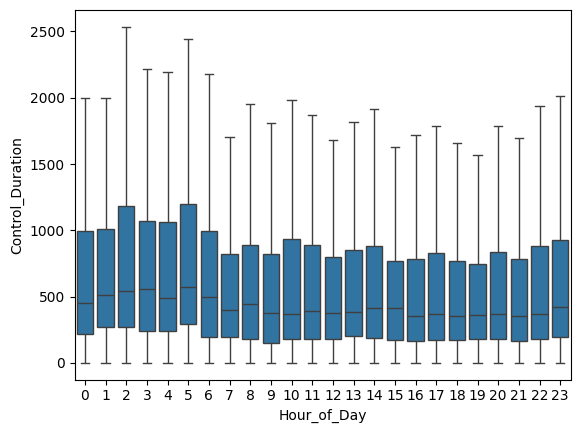

In [69]:
sns.boxplot(
    data=df_analysis,
    x="Hour_of_Day",
    y="Control_Duration",
    showfliers=False
)

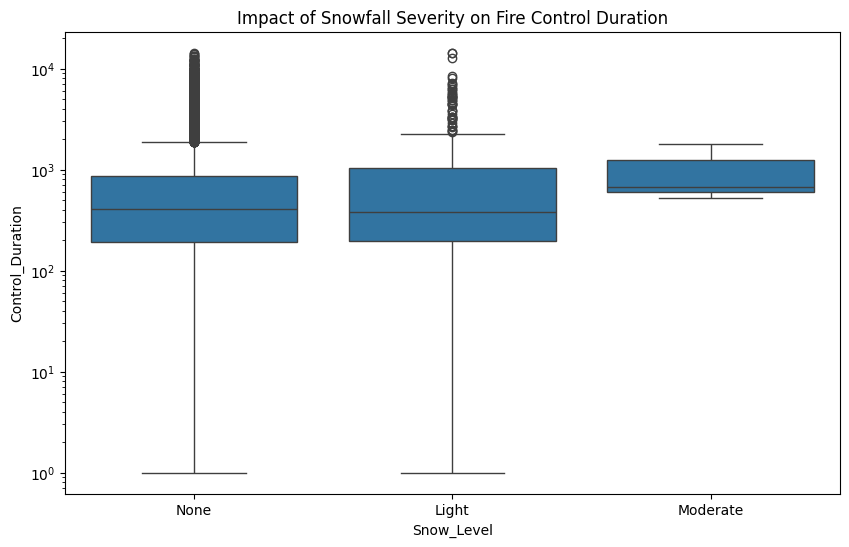

In [109]:
df_analysis['Snow_Level'] = pd.cut(df_analysis['snowfall'], 
                                   bins=[-1, 0, 2, 5], 
                                   labels=['None', 'Light', 'Moderate'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analysis, x='Snow_Level', y='Control_Duration')
plt.title('Impact of Snowfall Severity on Fire Control Duration')
plt.yscale('log')
plt.show()

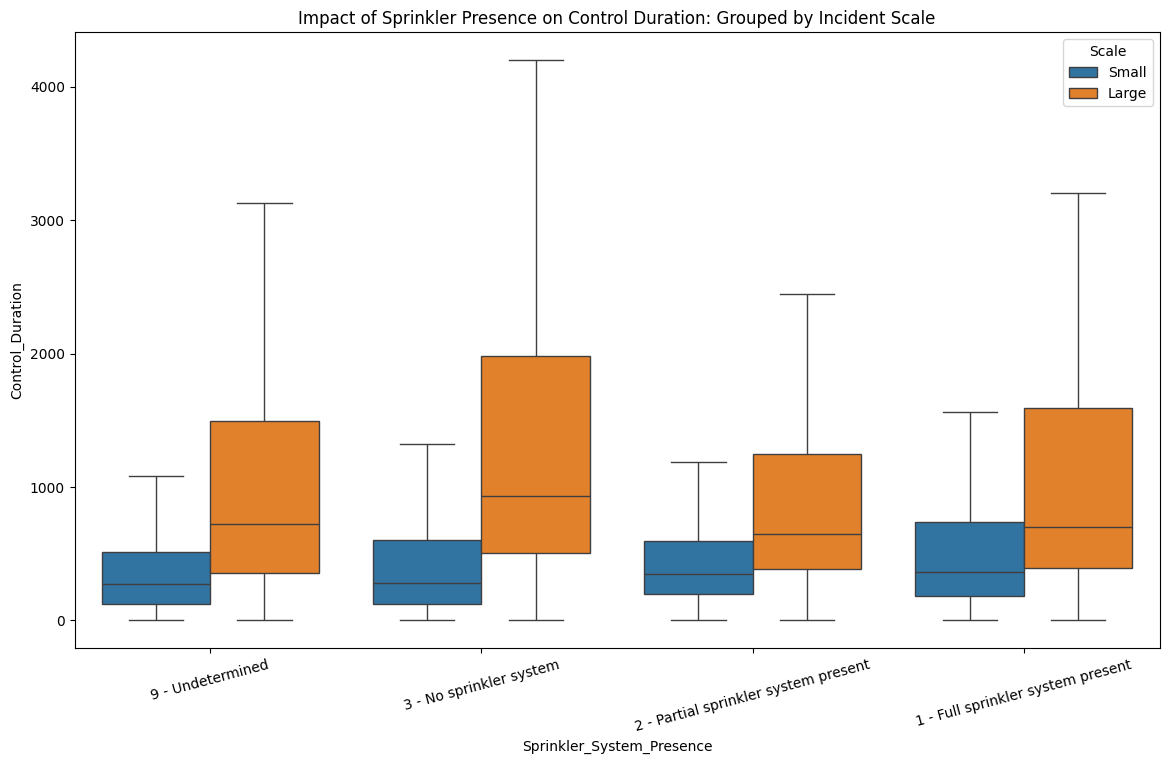

In [73]:
order = [
    '9 - Undetermined', 
    '3 - No sprinkler system', 
    '2 - Partial sprinkler system present', 
    '1 - Full sprinkler system present'
]
df_analysis['Scale'] = df_analysis['Number_of_responding_apparatus'].apply(lambda x: 'Small' if x <= 10 else 'Large')

plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df_analysis, 
    x='Sprinkler_System_Presence', 
    y='Control_Duration', 
    hue='Scale',
    order=order,
    showfliers=False
)
plt.title('Impact of Sprinkler Presence on Control Duration: Grouped by Incident Scale')
plt.xticks(rotation=15)
plt.show()

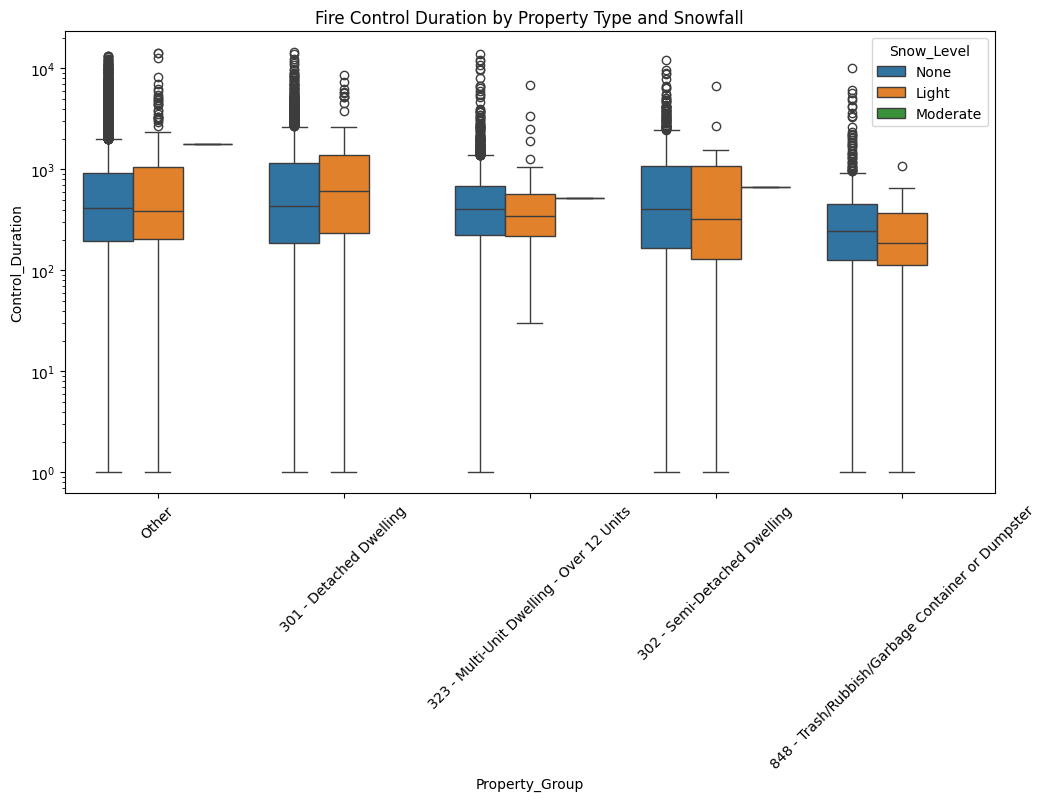

In [113]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_analysis,
    x="Property_Group",
    y="Control_Duration",
    hue="Snow_Level"
)

plt.yscale("log")
plt.xticks(rotation=45)

plt.title("Fire Control Duration by Property Type and Snowfall")
plt.show()